# Intrinsic vs projected neighbors


In this notebook, we study how neighborhood relationships between data points change when the data is projected onto a lower-dimensional space using PCA.
Our goal is not prediction, but understanding how dimensionality reduction affects local geometric structure.

Distance-based methods rely heavily on the notion of "nearness" between points. However, dimensionality reduction techniques such as PCA are designed to preserve global variance, not local distances. We need to observe to what extend PCA preserve neighborhoods.

In [17]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.join('..','src'))
from neighbor_metrics import knn_indices, average_neighbor_overlap, pairwise_distances, neighbor_overlap, avg_quality_difference
from preprocesing import robust_scaling

In [18]:
df_orig = pd.read_csv("../data/raw/Wine.csv")
df_proj_2d = pd.read_csv("../data/clean/wine_2d.csv")
df_proj_3d = pd.read_csv("../data/clean/wine_3d.csv")
quality = df_orig['quality']
df_orig = robust_scaling(df_orig.drop(['quality', 'Id'], axis=1))
df_orig

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.25,0.727273,-0.757576,-0.428571,-0.15,-0.142857,-0.075,0.492308,1.025641,-0.333333,-0.5000
1,-0.05,1.454545,-0.757576,0.571429,0.95,0.857143,0.750,0.052747,-0.564103,0.333333,-0.2500
2,-0.05,0.969697,-0.636364,0.142857,0.65,0.142857,0.425,0.140659,-0.256410,0.166667,-0.2500
3,1.65,-0.969697,0.939394,-0.428571,-0.20,0.285714,0.575,0.580220,-0.769231,-0.222222,-0.2500
4,-0.25,0.727273,-0.757576,-0.428571,-0.15,-0.142857,-0.075,0.492308,1.025641,-0.333333,-0.5000
...,...,...,...,...,...,...,...,...,...,...,...
1138,-0.80,-0.040404,-0.363636,0.142857,-0.15,1.142857,0.075,-0.413187,0.564103,0.722222,0.5000
1139,-0.55,0.404040,-0.515152,-0.428571,-0.55,1.071429,0.025,-0.074725,0.564103,1.111111,-0.4375
1140,-0.85,0.323232,-0.515152,-0.285714,0.55,1.357143,0.175,-0.782418,0.717949,-0.222222,0.1875
1141,-1.00,0.121212,-0.454545,0.000000,-0.85,1.857143,0.350,-0.685714,1.076923,0.777778,0.6250


First, we reuse the scaled data and the PCA-transformed data from previous notebooks in order to compare neighborhood structures across representations.
We deliberately use our own implementations rather than black-box tools such as scikit-learn, as this allows us to make each step of the process explicit and easier to interpret.

In [19]:
distances_orig = pairwise_distances(df_orig)
distances_proj_2d = pairwise_distances(df_proj_2d)
pd.DataFrame(distances_orig)

,0,1,2,3,4,5,6,7,8,9,...,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142
0,0.000000,2.772543,1.868539,3.644479,0.000000,0.303210,1.698335,2.069033,1.137537,2.082828,...,3.581431,3.805799,2.088107,3.342167,2.663974,2.489225,2.126643,2.368444,3.125139,2.273231
1,2.772543,0.000000,1.126700,3.867203,2.772543,2.806512,2.803422,3.569671,2.767437,2.173065,...,3.748993,3.634337,3.438655,3.230802,3.763832,2.662174,2.676390,2.509016,3.420538,2.933668
2,1.868539,1.126700,0.000000,3.291448,1.868539,1.916603,2.012597,2.796465,1.765176,1.500945,...,3.302060,3.395798,2.770956,2.905218,3.220869,2.295825,2.240580,2.224266,3.235745,2.602598
3,3.644479,3.867203,3.291448,0.000000,3.644479,3.535986,2.915747,3.892548,3.140823,3.366698,...,3.467968,3.437073,4.290345,4.225017,5.135253,3.754572,3.728923,4.023447,4.478653,4.306407
4,0.000000,2.772543,1.868539,3.644479,0.000000,0.303210,1.698335,2.069033,1.137537,2.082828,...,3.581431,3.805799,2.088107,3.342167,2.663974,2.489225,2.126643,2.368444,3.125139,2.273231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,2.489225,2.662174,2.295825,3.754572,2.489225,2.406441,2.687730,2.794247,2.343879,2.508667,...,1.750280,1.761462,1.598538,1.570034,2.587044,0.000000,1.386296,1.427204,1.235552,1.218899
1139,2.126643,2.676390,2.240580,3.728923,2.126643,2.023148,2.453913,2.609288,2.126936,2.551794,...,2.470720,2.409337,1.846220,2.148575,3.063576,1.386296,0.000000,2.030756,1.777391,1.356464
1140,2.368444,2.509016,2.224266,4.023447,2.368444,2.275546,2.390369,2.378864,2.414083,1.919910,...,2.826824,2.783802,1.804298,2.029807,2.020682,1.427204,2.030756,0.000000,1.928435,1.277100
1141,3.125139,3.420538,3.235745,4.478653,3.125139,3.002674,3.244115,3.156665,3.177141,3.364126,...,2.239653,1.967360,1.842026,1.989285,2.863150,1.235552,1.777391,1.928435,0.000000,1.221869


In [20]:
pd.DataFrame(distances_proj_2d)

,0,1,2,3,4,5,6,7,8,9,...,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142
0,0.000000,1.725645,1.170760,0.723248,0.000000,0.119075,0.459305,1.372588,0.130111,1.085469,...,0.864450,0.867211,0.747988,0.424562,0.803789,0.496418,0.146373,0.556084,0.773849,0.081704
1,1.725645,0.000000,0.580400,1.059491,1.725645,1.833057,2.184239,3.054536,1.730637,1.314372,...,1.889227,1.619578,2.471370,1.927135,2.147715,1.393881,1.831655,1.371372,2.164823,1.795673
2,1.170760,0.580400,0.000000,0.594250,1.170760,1.271990,1.624581,2.477278,1.193416,0.825707,...,1.501505,1.265964,1.918586,1.347341,1.572443,0.919901,1.288712,0.791625,1.707055,1.245381
3,0.723248,1.059491,0.594250,0.000000,0.723248,0.841134,1.174086,2.095621,0.695004,1.046096,...,0.910564,0.692396,1.441699,1.047725,1.376117,0.336369,0.800579,0.660879,1.120770,0.778927
4,0.000000,1.725645,1.170760,0.723248,0.000000,0.119075,0.459305,1.372588,0.130111,1.085469,...,0.864450,0.867211,0.747988,0.424562,0.803789,0.496418,0.146373,0.556084,0.773849,0.081704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,0.496418,1.393881,0.919901,0.336369,0.496418,0.612132,0.903729,1.841796,0.421521,1.202862,...,0.625476,0.478883,1.145894,0.897303,1.264983,0.000000,0.525241,0.708825,0.787497,0.525765
1139,0.146373,1.831655,1.288712,0.800579,0.146373,0.156950,0.379313,1.316560,0.106237,1.231471,...,0.773661,0.819808,0.642607,0.500154,0.874400,0.525241,0.000000,0.702358,0.638485,0.069623
1140,0.556084,1.371372,0.791625,0.660879,0.556084,0.608477,0.933830,1.703954,0.651687,0.537145,...,1.293429,1.187281,1.236262,0.568715,0.787702,0.708825,0.702358,0.000000,1.304914,0.636435
1141,0.773849,2.164823,1.707055,1.120770,0.773849,0.786765,0.745302,1.513913,0.657682,1.842044,...,0.399874,0.650289,0.762518,1.108406,1.455304,0.787497,0.638485,1.304914,0.000000,0.707371


The first function computes the pairwise distances between samples in the dataset. Although different distance metrics (such as Manhattan distance) could be considered, this work focuses exclusively on the Euclidean distance. This function serves as the basis for our K-nearest neighbors algorithm. As an illustrative example, we compare the distances between points in the original feature space and in the two-dimensional space obtained after a PCA linear projection, in order to observe how inter-point distances change under dimensionality reduction.

$$
d(x_i, x_j) = \sqrt{\sum_{l=1}^p (x_{il} - x_{jl})^2}
$$


## Neighborhood preservation under low-dimensional projection with k=10

In [21]:
knn_orig = knn_indices(df_orig, 10)
knn_proj_2d = knn_indices(df_proj_2d, 10)
knn_proj_3d = knn_indices(df_proj_3d, 10)

For each sample $x_i$, we define its $k$-nearest-neighbor set as

$$
\mathcal{N}_k(x_i) =
\{ x_j \mid x_j \text{ is among the } k \text{ closest points to } x_i \}
$$

with respect to the Euclidean distance.


In [22]:
pd.DataFrame(knn_orig)

,0,1,2,3,4,5,6,7,8,9
0,4,5,20,62,659,109,551,1107,1105,604
1,2,721,151,445,967,286,911,255,93,95
2,151,967,656,286,1,44,255,721,434,247
3,414,913,563,410,1103,79,175,417,273,612
4,0,5,20,62,659,109,551,1107,1105,604
...,...,...,...,...,...,...,...,...,...,...
1138,1083,882,908,909,1014,634,632,1142,1141,642
1139,1029,1083,1042,1080,1117,176,1142,1138,123,886
1140,634,632,617,882,642,908,909,1142,900,1087
1141,1001,999,1033,1142,1138,1083,1014,1117,1091,621


In [23]:
pd.DataFrame(knn_proj_3d)

,0,1,2,3,4,5,6,7,8,9
0,4,764,173,137,908,909,5,857,858,1139
1,372,536,351,967,721,38,526,1085,147,215
2,987,210,215,967,1066,151,681,926,269,247
3,896,262,266,803,454,296,302,1006,1008,758
4,0,764,173,137,908,909,5,857,858,1139
...,...,...,...,...,...,...,...,...,...,...
1138,1132,882,631,1041,634,632,1026,628,630,1011
1139,1102,1017,764,137,393,173,4,0,5,1061
1140,291,408,185,119,53,105,104,117,969,785
1141,1044,1110,999,1001,620,1109,948,1091,986,1033


This function uses the pairwise distance matrix to compute, for each sample, its nearest neighbors. The output is an n×k matrix, where n is the number of samples and k is the number of nearest neighbors. Each entry (i,j) contains the index of the j-th closest sample to the i-th sample.
This representation allows us to compare neighborhood structures across different feature spaces by directly analyzing how the nearest-neighbor relationships change under linear projection


In this first experiment, we choose the 10 nearest neighbors in order to compare local neighborhood structures. However, the neighborhood changes cannot be quantified by directly inspecting the neighbor index matrices. Therefore, we introduce an overlap metric based on set theory.

We define the neighborhood overlap for sample $x_i$ as

$$
\text{Overlap}_k(x_i) =
\frac{
\left| \mathcal{N}_k^{\text{orig}}(x_i)
\cap
\mathcal{N}_k^{\text{proj}}(x_i) \right|
}{k}
$$


And the global overlap score is defined as

$$
\text{Overlap}_k =
\frac{1}{n}
\sum_{i=1}^n
\text{Overlap}_k(x_i)
$$


In [24]:
overlap_2d = average_neighbor_overlap(knn_orig, knn_proj_2d)
overlap_3d = average_neighbor_overlap(knn_orig, knn_proj_3d)

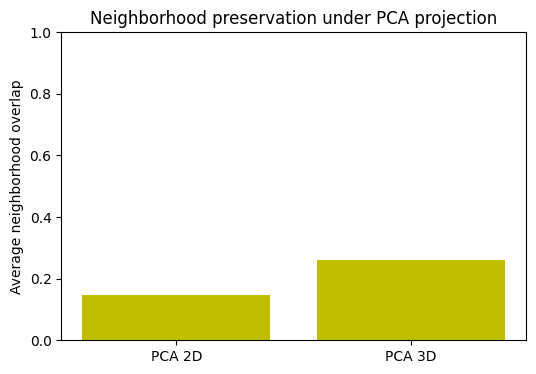

In [34]:
labels = ['PCA 2D', 'PCA 3D']
values = [overlap_2d, overlap_3d]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color='y')
plt.ylim(0, 1)

plt.ylabel('Average neighborhood overlap')
plt.title('Neighborhood preservation under PCA projection')
plt.savefig("../figs/PCA_preservation", bbox_inches="tight")
plt.show()

From the plot, we observe that the average neighborhood preservation is very low. This confirms that PCA must be used carefully when reducing the dimensionality of a dataset intended for distance-based algorithms, since the resulting neighborhoods can differ significantly from the original ones. Although the 3D PCA projection retains approximately 77% of the global variance, it does not preserve fine local geometric relationships.

In [26]:
overlap_points_2d = neighbor_overlap(knn_orig, knn_proj_2d)
overlap_points_3d = neighbor_overlap(knn_orig, knn_proj_3d)

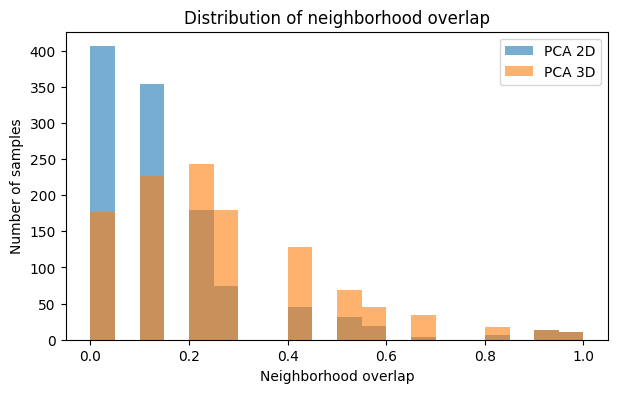

In [33]:
plt.figure(figsize=(7, 4))

plt.hist(overlap_points_2d, bins=20, alpha=0.6, label='PCA 2D')
plt.hist(overlap_points_3d, bins=20, alpha=0.6, label='PCA 3D')

plt.xlabel('Neighborhood overlap')
plt.ylabel('Number of samples')
plt.title('Distribution of neighborhood overlap')
plt.legend()
plt.savefig("../figs/neighborhood_overlap.png", bbox_inches="tight")
plt.show()


By analyzing the per-point neighborhood overlap in both 2D and 3D projections, we observe that the distributions are right-skewed. This indicates that most samples exhibit a low overlap, meaning that only a small fraction of their original neighbors are preserved after projection.

Although a few points achieve an overlap close to 1, these cases are rare. In particular, the PCA projection from ℝ¹¹ to ℝ² fails to preserve the local neighborhood structure for almost all points.

Comparing both histograms, we observe that the 3D projection consistently yields higher overlap values than the 2D projection. This suggests that increasing the number of principal components improves neighborhood preservation, although fine local geometric relationships are still not fully retained.

After analyzing how neighborhood structures change under projection, we now study whether these geometric distortions are related to the wine quality attribute.

Here we introduce a new metric to link quality with neighbor preservation.

For each point $x_i$

$$
\Delta_k =
\frac{1}{n}
\sum_{i=1}^{n}
\frac{1}{k}
\sum_{j \in \mathcal{N}_k(i)}
\left| q_i - q_j \right|
$$

This measures local semantic consistency


In [28]:
dq_orig = avg_quality_difference(knn_orig, quality)
dq_2d   = avg_quality_difference(knn_proj_2d, quality)
dq_3d   = avg_quality_difference(knn_proj_3d, quality)


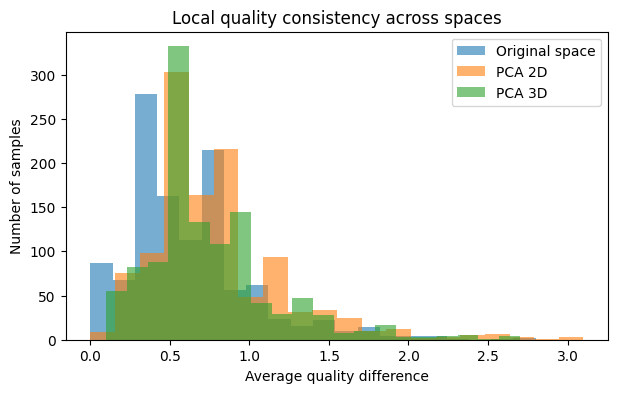

In [32]:
plt.figure(figsize=(7, 4))

plt.hist(dq_orig, bins=20, alpha=0.6, label='Original space')
plt.hist(dq_2d, bins=20, alpha=0.6, label='PCA 2D')
plt.hist(dq_3d, bins=20, alpha=0.6, label='PCA 3D')

plt.xlabel('Average quality difference')
plt.ylabel('Number of samples')
plt.title('Local quality consistency across spaces')
plt.legend()
plt.savefig("../figs/local_quality_across_spaces.png", bbox_inches="tight")
plt.show()


From the histogram, we observe that the distribution of average quality differences is similar across the original space and the PCA projections. However, the original space exhibits slightly lower average quality differences, indicating stronger local consistency in wine quality.

Despite the low neighborhood preservation observed in previous experiments, the PCA projections—particularly in 3D—still maintain comparable local relationships in terms of wine quality. This suggests that, although fine-grained geometric neighborhoods are distorted by dimensionality reduction, semantically meaningful structure related to wine quality is largely preserved.

## Neighborhood preservation under low-dimensional projection with k-different values

To assess the robustness of our results with respect to neighborhood size, we repeat the analysis for multiple values of 
𝑘

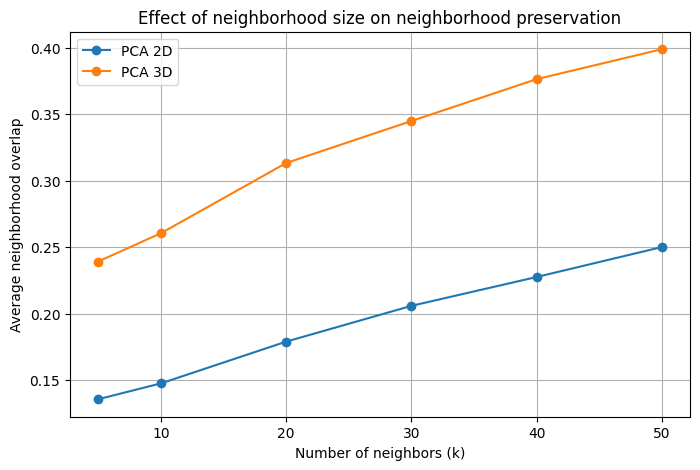

In [30]:
k_values = [5,10,20,30,40,50]
overlap_pca2 = []
overlap_pca3 = []

for k in k_values:
    knn_orig = knn_indices(df_orig, k)
    knn_pca2 = knn_indices(df_proj_2d, k)
    knn_pca3 = knn_indices(df_proj_3d, k)

    overlap_pca2.append(average_neighbor_overlap(knn_orig, knn_pca2))
    overlap_pca3.append(average_neighbor_overlap(knn_orig, knn_pca3))

plt.figure(figsize=(8, 5))

plt.plot(k_values, overlap_pca2, marker='o', label='PCA 2D')
plt.plot(k_values, overlap_pca3, marker='o', label='PCA 3D')

plt.xlabel('Number of neighbors (k)')
plt.ylabel('Average neighborhood overlap')
plt.title('Effect of neighborhood size on neighborhood preservation')
plt.legend()
plt.grid(True)
plt.savefig("../figs/overlap_vs_k.png", bbox_inches="tight")
plt.show()


From the plot, it is clear that the average neighborhood overlap increases as the number of neighbors k grows, indicating that larger neighborhoods are more likely to be partially preserved after dimensionality reduction.

Consistently across all values of k, the PCA 3D projection exhibits higher neighborhood overlap than the PCA 2D projection, confirming that increasing the number of principal components improves neighborhood preservation. Notably, this relative ordering remains stable as k varies, suggesting that neighborhood preservation is primarily influenced by the dimensionality of the embedding rather than the specific neighborhood size.

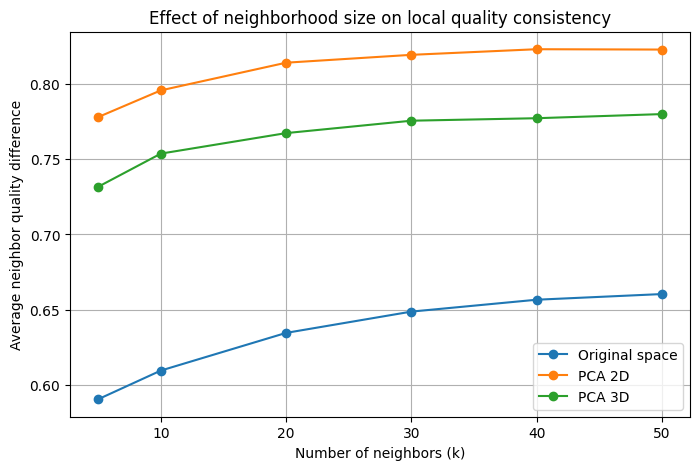

In [31]:
orig_scores = []
pca2_scores = []
pca3_scores = []

for k in k_values:
    knn_orig = knn_indices(df_orig, k)
    knn_pca2 = knn_indices(df_proj_2d, k)
    knn_pca3 = knn_indices(df_proj_3d, k)

    orig_scores.append(np.mean(avg_quality_difference(knn_orig, quality)))
    pca2_scores.append(np.mean(avg_quality_difference(knn_pca2, quality)))
    pca3_scores.append(np.mean(avg_quality_difference(knn_pca3, quality)))

plt.figure(figsize=(8, 5))

plt.plot(k_values, orig_scores, marker='o', label='Original space')
plt.plot(k_values, pca2_scores, marker='o', label='PCA 2D')
plt.plot(k_values, pca3_scores, marker='o', label='PCA 3D')

plt.xlabel('Number of neighbors (k)')
plt.ylabel('Average neighbor quality difference')
plt.title('Effect of neighborhood size on local quality consistency')
plt.legend()
plt.grid(True)
plt.savefig("../figs/quality_difference_vs_k.png", bbox_inches="tight")
plt.show()


Here we report the mean of the average quality difference across all samples as a function of the neighborhood size k. As expected, the average quality difference increases in all spaces as k grows, since larger neighborhoods are more likely to include samples with differing wine quality.

Importantly, the relative ordering of the curves remains stable across all values of k: the original space consistently exhibits the lowest average quality difference, followed by the PCA 3D projection, while PCA 2D shows the highest values. This indicates that increasing the dimensionality of the PCA embedding improves the preservation of local quality relationships.


## Project Conclusion

The experiments in this project highlight how linear projections onto lower-dimensional subspaces affect local neighborhood structure. As the number of retained principal components increases, the projection captures a larger portion of the variance of the original data, resulting in improved preservation of nearest-neighbor relationships, as measured by average neighborhood overlap. Conversely, projections onto very low-dimensional subspaces introduce distortions in Euclidean distances that significantly alter local neighborhoods.

Despite this geometric distortion, the average quality difference within neighborhoods remains comparatively stable across projection dimensions. This indicates that directions associated with large variance—which are preserved by PCA—also encode information relevant to wine quality. Consequently, although orthogonal projection onto a low-dimensional subspace reduces the fidelity of local geometric relationships, it can still preserve meaningful structure related to the target variable.

Overall, these results show that linear dimensionality reduction induces a trade-off between geometric accuracy and dimensionality, and that neighborhood-based metrics and quality-based metrics capture complementary aspects of the projected data.

These findings suggest that distance-based algorithms such as k-nearest neighbors may be sensitive to PCA-induced geometric distortions, particularly in low-dimensional projections, although performance on quality-related tasks may remain robust when relevant variance is preserved.